# CS 229 - HW1 EC3: Adversarial Alien Obfuscation

Compare different ways of obfuscating the math. If we use something semantic like "smash" instead of "glorp" to represent addition, is it easier or harder? Can you design strings of characters that reliably prevent learning?

See [AutoPrompt (Shin et al., EMNLP 2020)](https://aclanthology.org/2020.emnlp-main.346.pdf) for methods to automatically search for such prompts.


## Setup


In [1]:
# !pip install -q transformers torch peft accelerate tqdm


In [2]:
import torch, re, numpy as np, matplotlib.pyplot as plt
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float16, device_map="auto")
print(f"Loaded {MODEL_NAME}")


Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loaded Qwen/Qwen2.5-0.5B-Instruct


## Load Data


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
data = torch.load('drive/MyDrive/HW 1 Alien CalcGPT.pt', weights_only=False)


In [5]:
# data = torch.load('hw1_data.pt', weights_only=False)
train_problems  = data['train_problems']
train_answers   = data['train_answers']
train_levels    = data['train_levels']
train_standard  = data['train_standard']
test_problems   = data['test_problems']
test_answers    = data['test_answers']
test_levels     = data['test_levels']
test_standard   = data['test_standard']
operators       = data['operators']
print(f"Train: {len(train_problems)}, Test: {len(test_problems)}")
print(f"Original operators: {operators}")


Train: 300, Test: 150
Original operators: {'flarn': 'addition (+)', 'trok': 'multiplication (*)', 'snib': 'subtraction (-)', 'glorp': 'return result (identity wrapper)'}


## Helpers


In [6]:
def generate_response(messages, model, tokenizer, max_new_tokens=64):
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True)

def extract_answer(response):
    match = re.search(r"Final Answer:\s*(-?\d+)", response)
    return int(match.group(1)) if match else None

def run_eval(name, prompt_fn, problems, answers, levels, model, tokenizer, max_tokens=64):
    preds, outputs = [], []
    for problem in tqdm(problems, desc=name):
        resp = generate_response(prompt_fn(problem), model, tokenizer, max_tokens)
        preds.append(extract_answer(resp))
        outputs.append(resp)
    correct = sum(1 for p, a in zip(preds, answers) if p == a.item())
    total = len(answers)
    acc = correct / total
    print(f"  {name}: {correct}/{total} ({100*acc:.1f}%)")
    for level in [1, 2, 3]:
        idxs = [i for i in range(total) if levels[i].item() == level]
        lc = sum(1 for i in idxs if preds[i] == answers[i].item())
        print(f"    Level {level}: {lc}/{len(idxs)} ({100*lc/len(idxs):.1f}%)")
    return acc, preds, outputs


## Obfuscation Strategies

We define several alternative operator name mappings and test how they affect the model's ability to solve problems.

- **Original**: The alien names from the dataset (e.g., `glorp`, `flarn`)
- **Semantic**: Real English words hinting at the operation (e.g., `smash` for add, `shrink` for subtract)
- **Misleading**: Real English words suggesting the WRONG operation
- **Random gibberish**: Random character strings with no semantic content
- **Unicode**: Non-ASCII symbols that the model has likely never seen as operator names


In [7]:
# First, let's understand the original operator mapping
print("Original operator mapping:")
original_ops = {}
for name, desc in operators.items():
    print(f"  {name} -> {desc}")
    original_ops[name] = desc

# Extract the original operator names from the data
original_names = list(operators.keys())
print(f"\nOperator names: {original_names}")

# Look at a few problems to understand the format
for i in range(3):
    print(f"Problem: {test_problems[i]}")
    print(f"Standard: {test_standard[i]} = {test_answers[i].item()}")
    print()


Original operator mapping:
  flarn -> addition (+)
  trok -> multiplication (*)
  snib -> subtraction (-)
  glorp -> return result (identity wrapper)

Operator names: ['flarn', 'trok', 'snib', 'glorp']
Problem: glorp(flarn(9, 7))
Standard: 9 + 7 = 16

Problem: glorp(snib(13, 10))
Standard: 13 - 10 = 3

Problem: glorp(flarn(11, 16))
Standard: 11 + 16 = 27



In [8]:
# Define obfuscation mappings
# Each maps original_name -> new_name
obfuscation_schemes = {
    "original": {name: name for name in original_names},
    "semantic": {},      # Semantically related words
    "misleading": {},    # Words suggesting the wrong operation
    "gibberish": {},     # Random character strings
    "unicode": {},       # Unicode symbols
}

# We need to map based on what each operator actually does
# Let's categorize them first
print("Categorizing operators by their descriptions:")
for name, desc in operators.items():
    desc_lower = desc.lower()
    print(f"  {name}: {desc}")

# Build the semantic/misleading/gibberish/unicode mappings
# We'll create generic replacements since we don't know the exact ops ahead of time
import random, string

for i, name in enumerate(original_names):
    # Semantic: words that hint at math
    semantic_words = ["combine", "shrink", "scale", "split", "boost", "merge", "halve", "double"]
    obfuscation_schemes["semantic"][name] = semantic_words[i % len(semantic_words)]
    
    # Misleading: words suggesting unrelated concepts
    misleading_words = ["paint", "dance", "swim", "cook", "sleep", "sing", "jump", "fly"]
    obfuscation_schemes["misleading"][name] = misleading_words[i % len(misleading_words)]
    
    # Gibberish: random strings
    random.seed(42 + i)
    obfuscation_schemes["gibberish"][name] = ''.join(random.choices(string.ascii_lowercase, k=5))
    
    # Unicode: unusual symbols
    unicode_ops = ["∆", "⊕", "⊗", "∇", "⊘", "⊙", "⊛", "⊞"]
    obfuscation_schemes["unicode"][name] = unicode_ops[i % len(unicode_ops)]

print("\nObfuscation schemes:")
for scheme, mapping in obfuscation_schemes.items():
    print(f"  {scheme}: {mapping}")


Categorizing operators by their descriptions:
  flarn: addition (+)
  trok: multiplication (*)
  snib: subtraction (-)
  glorp: return result (identity wrapper)

Obfuscation schemes:
  original: {'flarn': 'flarn', 'trok': 'trok', 'snib': 'snib', 'glorp': 'glorp'}
  semantic: {'flarn': 'combine', 'trok': 'shrink', 'snib': 'scale', 'glorp': 'split'}
  misleading: {'flarn': 'paint', 'trok': 'dance', 'snib': 'swim', 'glorp': 'cook'}
  gibberish: {'flarn': 'qahft', 'trok': 'bsdmr', 'snib': 'kowef', 'glorp': 'hmcib'}
  unicode: {'flarn': '∆', 'trok': '⊕', 'snib': '⊗', 'glorp': '∇'}


In [9]:
def remap_problem(problem, mapping):
    """Replace operator names in a problem string using the mapping."""
    result = problem
    for old_name, new_name in mapping.items():
        result = result.replace(old_name, new_name)
    return result

def remap_operators(operators, mapping):
    """Remap operator descriptions to use new names."""
    new_ops = {}
    for old_name, desc in operators.items():
        new_name = mapping[old_name]
        new_ops[new_name] = desc
    return new_ops

# Verify remapping works
for scheme, mapping in obfuscation_schemes.items():
    remapped = remap_problem(test_problems[0], mapping)
    print(f"{scheme:12s}: {remapped}")


original    : glorp(flarn(9, 7))
semantic    : split(combine(9, 7))
misleading  : cook(paint(9, 7))
gibberish   : hmcib(qahft(9, 7))
unicode     : ∇(∆(9, 7))


## Run Experiments


In [10]:
results = {}

for scheme_name, mapping in obfuscation_schemes.items():
    print(f"\n{'='*60}")
    print(f"Scheme: {scheme_name}")
    print(f"{'='*60}")
    
    remapped_ops = remap_operators(operators, mapping)
    
    def build_prompt(problem, _ops=remapped_ops, _map=mapping):
        remapped = remap_problem(problem, _map)
        sys = "You are an expert mathematician who understands the following alien operators:\n"
        for name, desc in _ops.items():
            sys += f"- {name}(...) = {desc}\n"
        return [{'role': "system", 'content': sys},
                {'role': "user", 'content': f"What is {remapped}? Respond with: Final Answer: <number>"}]
    
    acc, preds, outputs = run_eval(
        scheme_name, build_prompt, test_problems, test_answers, test_levels, model, tokenizer
    )
    results[scheme_name] = {"accuracy": acc, "predictions": preds, "raw_outputs": outputs}



Scheme: original


original: 100%|██████████| 150/150 [00:08<00:00, 18.20it/s]


  original: 17/150 (11.3%)
    Level 1: 15/50 (30.0%)
    Level 2: 1/50 (2.0%)
    Level 3: 1/50 (2.0%)

Scheme: semantic


semantic: 100%|██████████| 150/150 [00:08<00:00, 18.02it/s]


  semantic: 0/150 (0.0%)
    Level 1: 0/50 (0.0%)
    Level 2: 0/50 (0.0%)
    Level 3: 0/50 (0.0%)

Scheme: misleading


...

  misleading: 0/150 (0.0%)
    Level 1: 0/50 (0.0%)
    Level 2: 0/50 (0.0%)
    Level 3: 0/50 (0.0%)

Scheme: gibberish


gibberish: 100%|██████████| 150/150 [00:07<00:00, 20.98it/s]


  gibberish: 15/150 (10.0%)
    Level 1: 14/50 (28.0%)
    Level 2: 0/50 (0.0%)
    Level 3: 1/50 (2.0%)

Scheme: unicode


unicode: 100%|██████████| 150/150 [00:07<00:00, 20.03it/s]

  unicode: 9/150 (6.0%)
    Level 1: 8/50 (16.0%)
    Level 2: 0/50 (0.0%)
    Level 3: 1/50 (2.0%)


## Results


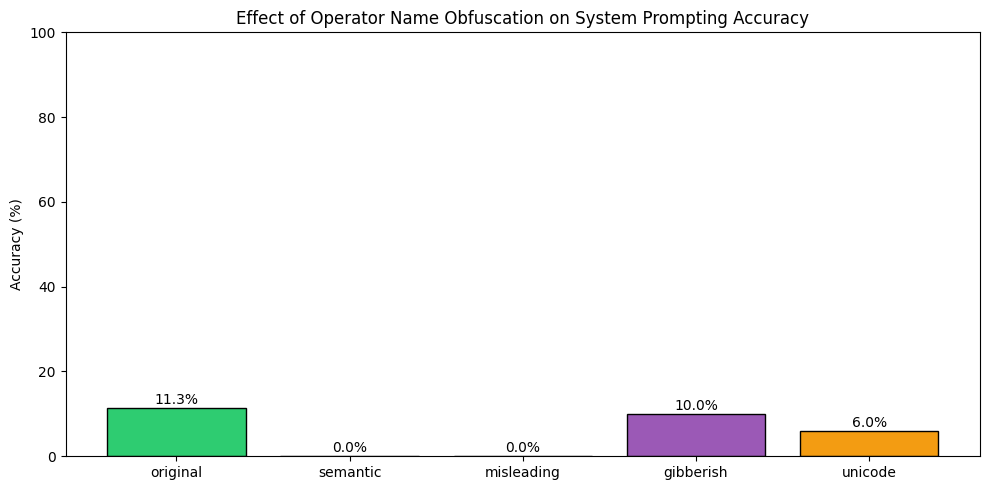

In [11]:
# Bar chart comparing obfuscation schemes
schemes = list(results.keys())
accs = [results[s]["accuracy"] * 100 for s in schemes]
colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6', '#f39c12']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(schemes, accs, color=colors[:len(schemes)], edgecolor='black')
ax.set_ylabel("Accuracy (%)")
ax.set_title("Effect of Operator Name Obfuscation on System Prompting Accuracy")
ax.set_ylim(0, 100)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+1, f"{acc:.1f}%", ha='center', fontsize=10)
plt.tight_layout()
plt.show()


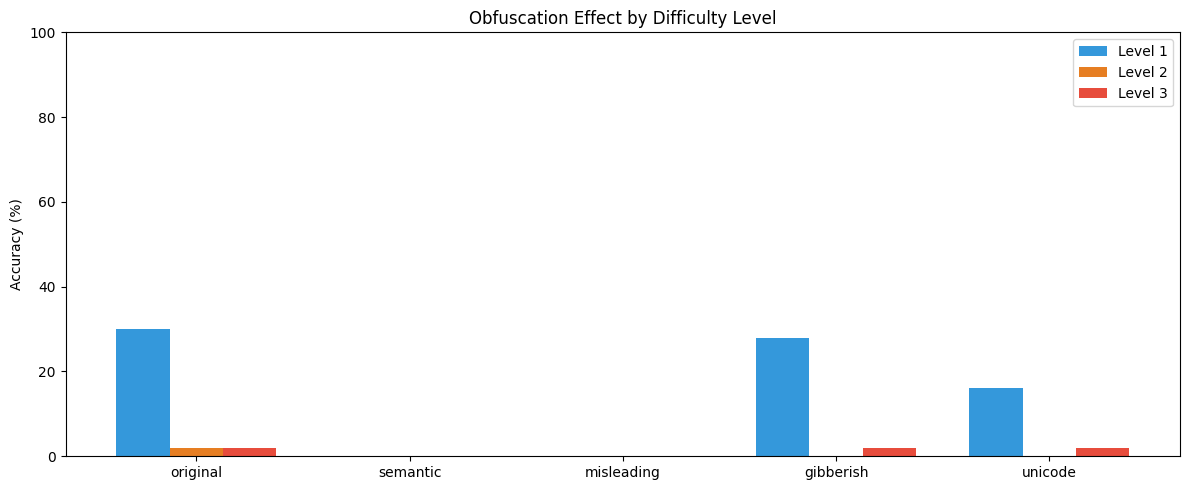

In [12]:
# Per-level breakdown
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(schemes))
width = 0.25
level_colors = ['#3498db', '#e67e22', '#e74c3c']

for li, level in enumerate([1, 2, 3]):
    level_accs = []
    for s in schemes:
        preds = results[s]["predictions"]
        idxs = [j for j in range(len(test_levels)) if test_levels[j].item() == level]
        lc = sum(1 for j in idxs if preds[j] == test_answers[j].item())
        level_accs.append(100 * lc / len(idxs))
    ax.bar(x + li * width, level_accs, width, label=f"Level {level}", color=level_colors[li])

ax.set_ylabel("Accuracy (%)")
ax.set_title("Obfuscation Effect by Difficulty Level")
ax.set_xticks(x + width)
ax.set_xticklabels(schemes)
ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()


In [13]:
# Sample failures for each scheme
for scheme_name in schemes:
    preds = results[scheme_name]["predictions"]
    outputs = results[scheme_name]["raw_outputs"]
    print(f"\n--- Sample failures: {scheme_name} ---")
    count = 0
    for i in range(len(preds)):
        if preds[i] != test_answers[i].item():
            print(f"  Problem:  {test_problems[i]}")
            print(f"  Standard: {test_standard[i]} = {test_answers[i].item()}")
            print(f"  Got:      {preds[i]}")
            print(f"  Output:   {outputs[i][:200]}")
            print()
            count += 1
            if count >= 2:
                break



--- Sample failures: original ---
  Problem:  glorp(flarn(9, 7))
  Standard: 9 + 7 = 16
  Got:      2
  Output:   Final Answer: 2

  Problem:  glorp(flarn(11, 16))
  Standard: 11 + 16 = 27
  Got:      5
  Output:   Final Answer: 5.


--- Sample failures: semantic ---
  Problem:  glorp(flarn(9, 7))
  Standard: 9 + 7 = 16
  Got:      None
  Output:   The final answer is: <number>

  Problem:  glorp(snib(13, 10))
  Standard: 13 - 10 = 3
  Got:      None
  Output:   The final answer is 1.3.


--- Sample failures: misleading ---
  Problem:  glorp(flarn(9, 7))
  Standard: 9 + 7 = 16
  Got:      None
  Output:   The final answer is 2.

  Problem:  glorp(snib(13, 10))
  Standard: 13 - 10 = 3
  Got:      None
  Output:   The final answer is 23.


--- Sample failures: gibberish ---
  Problem:  glorp(flarn(9, 7))
  Standard: 9 + 7 = 16
  Got:      2
  Output:   Final Answer: 2

  Problem:  glorp(snib(13, 10))
  Standard: 13 - 10 = 3
  Got:      13
  Output:   Final Answer: 13


--- Sample failur

## Analysis

*TODO: Write a short paragraph (4–6 sentences). Which obfuscation is hardest for the model? Does semantic meaning in the operator name help or hurt? Can misleading names actively decrease performance below random gibberish?*
